# 04 — Optimization Comparison: Bayesian Optimization (Optuna) vs. PSO

Tunes both models flagged in Phase 2/3 as needing it: **SVM** (fixed hyperparameters degraded
sharply under cross-load generalization, 0.831 accuracy) and the **1D CNN** (the literal
"best-performing model from Phases 2-3" per the project plan, 0.918 accuracy). Both optimizers
search the *same* continuous space and call the *same* objective
(`src/optimization/tuning.py`, `src/optimization/objectives.py`), scored on an inner
validation split carved out of loads 0-2 - **never** the held-out load-3 test set, to avoid
leaking test data into hyperparameter selection (same leakage discipline as every prior phase,
see [docs/datasets.md](../docs/datasets.md)). Final comparison retrains each method's winning
config on the full train set and evaluates once on held-out load 3.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader

from src.data.cwru import build_windowed_dataset, SAMPLE_RATE_HZ
from src.data.features import build_feature_matrix
from src.data.torch_utils import WindowDataset, compute_train_stats
from src.models.baseline import time_contiguous_split
from src.models.cnn import Cnn1D, train_cnn, predict
from src.optimization.objectives import make_svm_objective, make_cnn_objective
from src.optimization.tuning import run_optuna, run_pso

CWRU_DIR = Path.cwd().parent / "data" / "raw" / "cwru"
WINDOW_SIZE = 2048
TEST_LOAD = 3
torch.manual_seed(42)
np.random.seed(42)


## Load, window, and split (identical protocol to Phase 2)

In [2]:
windows, labels, loads, file_ids = build_windowed_dataset(CWRU_DIR, window_size=WINDOW_SIZE)
train_mask = loads != TEST_LOAD
test_mask = loads == TEST_LOAD
inner_train_mask, inner_val_mask = time_contiguous_split(file_ids[train_mask], test_fraction=0.15)
print("train:", inner_train_mask.sum(), "val:", inner_val_mask.sum(), "test:", test_mask.sum())


train: 1853 val: 331 test: 769


# Part A — Tuning the SVM

Fast to fit (fractions of a second), so both optimizers get a generous, evenly matched budget:
40 evaluations each.


In [3]:
features_df = build_feature_matrix(windows, fs=SAMPLE_RATE_HZ)

X_train_feat = features_df[train_mask].reset_index(drop=True)[inner_train_mask].reset_index(drop=True)
X_val_feat = features_df[train_mask].reset_index(drop=True)[inner_val_mask].reset_index(drop=True)
X_test_feat = features_df[test_mask].reset_index(drop=True)
X_full_train_feat = features_df[train_mask].reset_index(drop=True)  # inner-train + inner-val, for final retrain

y_train_feat = labels[train_mask][inner_train_mask]
y_val_feat = labels[train_mask][inner_val_mask]
y_test_feat = labels[test_mask]
y_full_train_feat = labels[train_mask]

svm_objective = make_svm_objective(X_train_feat, y_train_feat, X_val_feat, y_val_feat)
svm_param_space = {"C": ("float_log", 1e-2, 1e3), "gamma": ("float_log", 1e-4, 1e1)}


In [4]:
svm_optuna_history = run_optuna(svm_objective, svm_param_space, n_trials=40, seed=42)
svm_pso_history = run_pso(svm_objective, svm_param_space, n_particles=8, n_iters=5, seed=42)

print(f"Optuna: {len(svm_optuna_history)} evals, best val acc = {svm_optuna_history[-1]['best_so_far']:.4f}, "
      f"wall time = {svm_optuna_history[-1]['wall_time_s']:.1f}s")
print(f"PSO:    {len(svm_pso_history)} evals, best val acc = {svm_pso_history[-1]['best_so_far']:.4f}, "
      f"wall time = {svm_pso_history[-1]['wall_time_s']:.1f}s")


Optuna: 40 evals, best val acc = 0.9970, wall time = 3.9s
PSO:    40 evals, best val acc = 0.9970, wall time = 3.0s


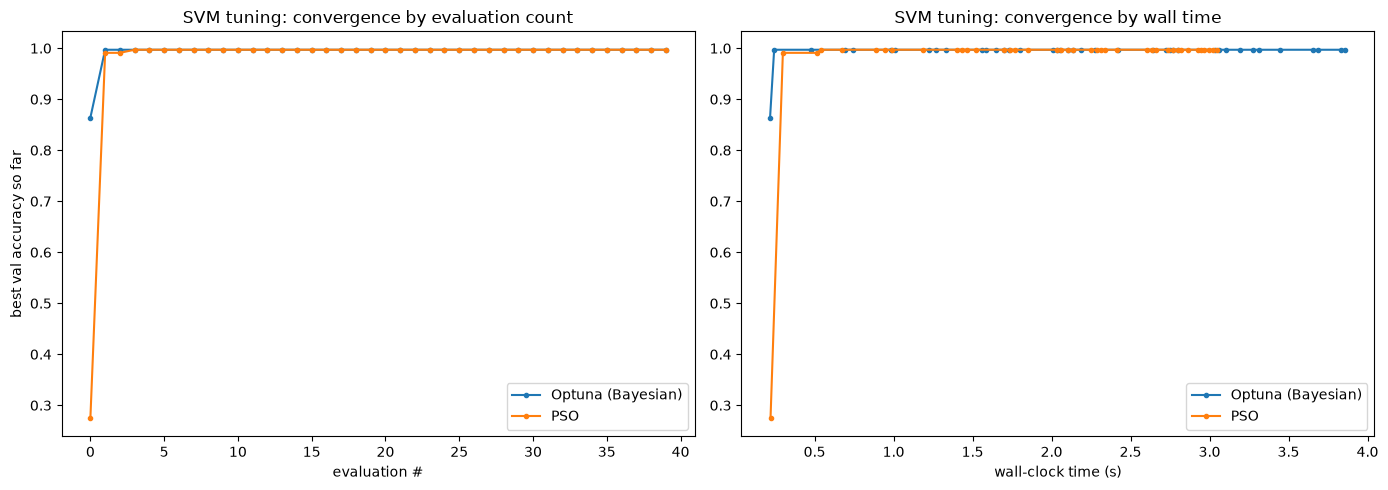

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for history, label in [(svm_optuna_history, "Optuna (Bayesian)"), (svm_pso_history, "PSO")]:
    df = pd.DataFrame(history)
    axes[0].plot(df["eval"], df["best_so_far"], marker="o", markersize=3, label=label)
    axes[1].plot(df["wall_time_s"], df["best_so_far"], marker="o", markersize=3, label=label)
axes[0].set_xlabel("evaluation #")
axes[0].set_ylabel("best val accuracy so far")
axes[0].set_title("SVM tuning: convergence by evaluation count")
axes[0].legend()
axes[1].set_xlabel("wall-clock time (s)")
axes[1].set_title("SVM tuning: convergence by wall time")
axes[1].legend()
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase4_svm_convergence.png", dpi=150)
plt.show()


In [6]:
svm_optuna_best_params = max(svm_optuna_history, key=lambda r: r["score"])["params"]
svm_pso_best_params = max(svm_pso_history, key=lambda r: r["score"])["params"]
print("Optuna best params:", svm_optuna_best_params)
print("PSO best params:   ", svm_pso_best_params)

svm_results = {}
for name, params in [("SVM (fixed, Phase 2)", {"C": 10, "gamma": "scale"}),
                      ("SVM (Optuna-tuned)", svm_optuna_best_params),
                      ("SVM (PSO-tuned)", svm_pso_best_params)]:
    model = make_pipeline(StandardScaler(), SVC(kernel="rbf", **params))
    model.fit(X_full_train_feat, y_full_train_feat)
    acc = model.score(X_test_feat, y_test_feat)
    svm_results[name] = acc
    print(f"{name}: held-out-load-3 accuracy = {acc:.4f}")


Optuna best params: {'C': 45.70563099801453, 'gamma': 0.09846738873614563}
PSO best params:    {'C': np.float64(26.373339933815245), 'gamma': np.float64(0.015876781526923997)}
SVM (fixed, Phase 2): held-out-load-3 accuracy = 0.8309
SVM (Optuna-tuned): held-out-load-3 accuracy = 0.8257
SVM (PSO-tuned): held-out-load-3 accuracy = 0.8362


# Part B — Tuning the 1D CNN

Each evaluation is a full (short) training run, so both optimizers get a smaller, evenly
matched budget: 15 evaluations each, 12 epochs per evaluation (vs. 30 for the final retrain).


In [7]:
de_train = windows[train_mask][inner_train_mask]
de_val = windows[train_mask][inner_val_mask]
de_test = windows[test_mask]
de_full_train = windows[train_mask]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_

y_train_cnn = y_all[train_mask][inner_train_mask]
y_val_cnn = y_all[train_mask][inner_val_mask]
y_test_cnn = y_all[test_mask]
y_full_train_cnn = y_all[train_mask]

train_mean, train_std = compute_train_stats(de_train)
train_loader = DataLoader(WindowDataset(de_train, y_train_cnn, train_mean, train_std), batch_size=64, shuffle=True)
val_loader = DataLoader(WindowDataset(de_val, y_val_cnn, train_mean, train_std), batch_size=64)

cnn_objective = make_cnn_objective(train_loader, val_loader, num_classes=len(class_names), epochs=12)
cnn_param_space = {"lr": ("float_log", 1e-4, 3e-2), "dropout": ("float", 0.0, 0.6), "width_mult": ("float", 0.5, 2.0)}


In [8]:
cnn_optuna_history = run_optuna(cnn_objective, cnn_param_space, n_trials=15, seed=42)
cnn_pso_history = run_pso(cnn_objective, cnn_param_space, n_particles=5, n_iters=3, seed=42)

print(f"Optuna: {len(cnn_optuna_history)} evals, best val acc = {cnn_optuna_history[-1]['best_so_far']:.4f}, "
      f"wall time = {cnn_optuna_history[-1]['wall_time_s']:.1f}s")
print(f"PSO:    {len(cnn_pso_history)} evals, best val acc = {cnn_pso_history[-1]['best_so_far']:.4f}, "
      f"wall time = {cnn_pso_history[-1]['wall_time_s']:.1f}s")


Optuna: 15 evals, best val acc = 1.0000, wall time = 75.4s
PSO:    15 evals, best val acc = 1.0000, wall time = 86.4s


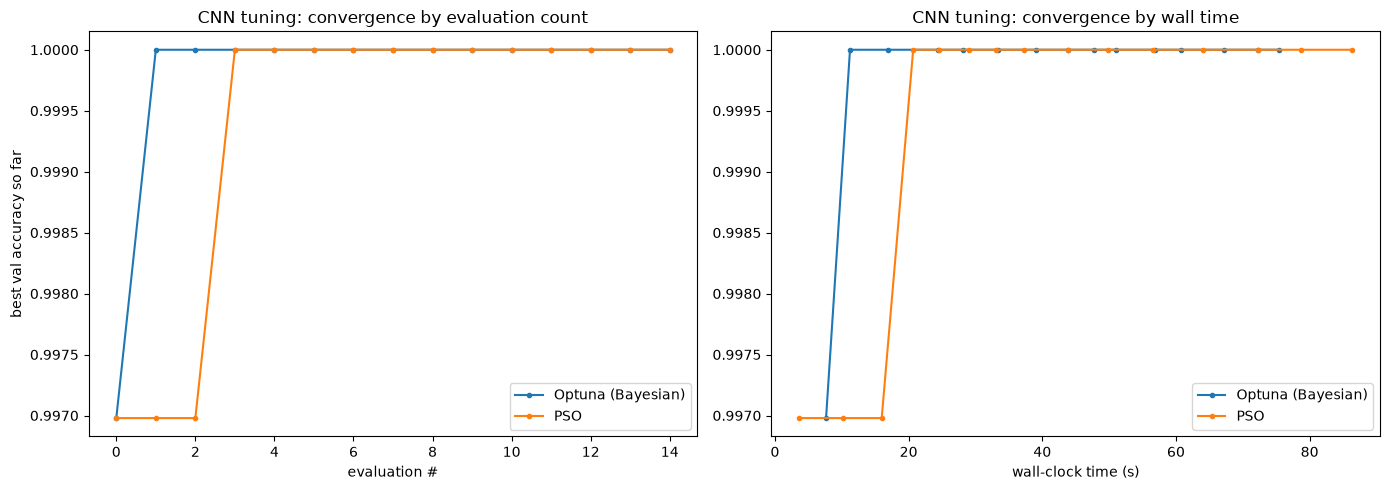

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for history, label in [(cnn_optuna_history, "Optuna (Bayesian)"), (cnn_pso_history, "PSO")]:
    df = pd.DataFrame(history)
    axes[0].plot(df["eval"], df["best_so_far"], marker="o", markersize=3, label=label)
    axes[1].plot(df["wall_time_s"], df["best_so_far"], marker="o", markersize=3, label=label)
axes[0].set_xlabel("evaluation #")
axes[0].set_ylabel("best val accuracy so far")
axes[0].set_title("CNN tuning: convergence by evaluation count")
axes[0].legend()
axes[1].set_xlabel("wall-clock time (s)")
axes[1].set_title("CNN tuning: convergence by wall time")
axes[1].legend()
fig.tight_layout()
plt.savefig(Path.cwd().parent / "docs" / "phase4_cnn_convergence.png", dpi=150)
plt.show()


In [10]:
cnn_optuna_best_params = max(cnn_optuna_history, key=lambda r: r["score"])["params"]
cnn_pso_best_params = max(cnn_pso_history, key=lambda r: r["score"])["params"]
print("Optuna best params:", cnn_optuna_best_params)
print("PSO best params:   ", cnn_pso_best_params)

full_train_loader = DataLoader(
    WindowDataset(de_full_train, y_full_train_cnn, train_mean, train_std), batch_size=64, shuffle=True
)
test_loader = DataLoader(WindowDataset(de_test, y_test_cnn, train_mean, train_std), batch_size=64)

cnn_results = {}
for name, params in [("1D CNN (fixed, Phase 2)", {"lr": 1e-3, "dropout": 0.0, "width_mult": 1.0}),
                      ("1D CNN (Optuna-tuned)", cnn_optuna_best_params),
                      ("1D CNN (PSO-tuned)", cnn_pso_best_params)]:
    # reset the seed before EACH final retrain - otherwise differences in accuracy would
    # partly reflect random init/shuffling luck rather than the hyperparameters themselves
    torch.manual_seed(42)
    model = Cnn1D(num_classes=len(class_names), width_mult=params["width_mult"], dropout=params["dropout"])
    train_cnn(model, full_train_loader, test_loader, epochs=30, lr=params["lr"])
    preds, targets = predict(model, test_loader)
    acc = (preds == targets).mean()
    cnn_results[name] = acc
    print(f"{name}: held-out-load-3 accuracy = {acc:.4f}")


Optuna best params: {'lr': 0.0030405325392865654, 'dropout': 0.0936111842654619, 'width_mult': 0.7339917805043039}
PSO best params:    {'lr': np.float64(0.0012311503632415647), 'dropout': np.float64(0.07322294090686729), 'width_mult': np.float64(1.2427653651669053)}


1D CNN (fixed, Phase 2): held-out-load-3 accuracy = 0.9298


1D CNN (Optuna-tuned): held-out-load-3 accuracy = 0.9987


1D CNN (PSO-tuned): held-out-load-3 accuracy = 0.9987


## Final comparison

In [11]:
summary = pd.DataFrame(
    [{"model": k, "accuracy": v} for k, v in {**svm_results, **cnn_results}.items()]
).sort_values("accuracy", ascending=False).reset_index(drop=True)
summary


,model,accuracy
0,1D CNN (Optuna-tuned),0.998700
1,1D CNN (PSO-tuned),0.998700
2,"1D CNN (fixed, Phase 2)",0.929779
3,SVM (PSO-tuned),0.836151
4,"SVM (fixed, Phase 2)",0.830949
5,SVM (Optuna-tuned),0.825748


In [12]:
cost_summary = pd.DataFrame([
    {"target": "SVM", "optimizer": "Optuna", "evals": len(svm_optuna_history),
     "wall_time_s": svm_optuna_history[-1]["wall_time_s"], "best_val_acc": svm_optuna_history[-1]["best_so_far"]},
    {"target": "SVM", "optimizer": "PSO", "evals": len(svm_pso_history),
     "wall_time_s": svm_pso_history[-1]["wall_time_s"], "best_val_acc": svm_pso_history[-1]["best_so_far"]},
    {"target": "CNN", "optimizer": "Optuna", "evals": len(cnn_optuna_history),
     "wall_time_s": cnn_optuna_history[-1]["wall_time_s"], "best_val_acc": cnn_optuna_history[-1]["best_so_far"]},
    {"target": "CNN", "optimizer": "PSO", "evals": len(cnn_pso_history),
     "wall_time_s": cnn_pso_history[-1]["wall_time_s"], "best_val_acc": cnn_pso_history[-1]["best_so_far"]},
])
cost_summary


,target,optimizer,evals,wall_time_s,best_val_acc
0,SVM,Optuna,40,3.860616,0.996979
1,SVM,PSO,40,3.047775,0.996979
2,CNN,Optuna,15,75.442492,1.000000
3,CNN,PSO,15,86.386034,1.000000
